# So sanh model du bao gia ca phe Robusta noi dia (theo ngay)

**Muc tieu:** du bao muc gia `Gia_target` (TB Dak Lak + Lam Dong, VND/kg) theo ngay, chi dung **ML co dien** (khong deep learning).

**Du lieu:** `gia_cafe_master.csv` — 1.566 ngay lam viec (2020-2025), 18 feature (tu hoi quy gia + lich + London/ty gia + dau diesel + xuat khau + thoi tiet/ONI).

**Pipeline:**
1. Nap & chuan bi du lieu (xu ly NaN, chong ro ri)
2. Chon khung target: `level` (muc gia) hoac `delta` (thay doi) — delta giup mo hinh cay ngoai suy duoc tren dinh gia ky luc
3. Metric: MAE, RMSE, sMAPE, MASE, Directional Accuracy
4. Walk-forward CV (cua so mo rong)
5. Bo model: Naive, ARIMAX, Ridge/Lasso/ElasticNet, RandomForest, XGBoost, LightGBM, SVR, kNN
6. Bang ket qua + truc quan + feature importance + kiem dinh Diebold-Mariano

> Tat ca model deu duoc danh gia tren **muc gia** de so sanh cong bang.

In [14]:
# Neu chay tren Colab/may chua co thu vien, bo comment dong duoi:
# !pip install scikit-learn scipy statsmodels xgboost lightgbm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

HAS_XGB = True
try:
    from xgboost import XGBRegressor
except Exception:
    HAS_XGB = False

HAS_LGB = True
try:
    from lightgbm import LGBMRegressor
except Exception:
    HAS_LGB = False

HAS_SM = True
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
except Exception:
    HAS_SM = False

plt.rcParams['figure.figsize'] = (12, 5)
print('xgboost:', HAS_XGB, '| lightgbm:', HAS_LGB, '| statsmodels:', HAS_SM)

xgboost: True | lightgbm: True | statsmodels: True


## 1. Nap du lieu

In [15]:
CSV_PATH = 'data/processed/gia_cafe_master_full.csv'
df = pd.read_csv(CSV_PATH, parse_dates=['Ngay']).sort_values('Ngay').reset_index(drop=True)
df = df.set_index('Ngay')
print('Shape:', df.shape)
print('Khoang thoi gian:', df.index.min().date(), '->', df.index.max().date())
df.head()

Shape: (1566, 26)
Khoang thoi gian: 2020-01-01 -> 2025-12-31


,Gia_target,outlier_flag,target_lag1,target_lag2,target_lag3,target_ret_lag1,MA5,MA10,std5,dayofweek,...,rain_90d,oni,waterbal_90d,Luong_lag1m,dongia_lag1m,dongia_ret_lag1m,area_tn,prod_tn,yield_tn,tonkho_tan
Ngay,,,,,,,,,,,,,,,,,,,,,
2020-01-01,32319.5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,203.479996,0.58,-142.271622,87.5,1800.800000,-0.014087,618.0,1511494.4,2.445784,33360.0
2020-01-02,32319.5,0,32319.5,NaN,NaN,NaN,NaN,NaN,NaN,3,...,188.599996,0.58,-157.761064,87.5,1800.800000,-0.014087,618.0,1511494.4,2.445784,33360.0
2020-01-03,32269.5,0,32319.5,32319.5,NaN,0.000000,NaN,NaN,NaN,4,...,180.959996,0.58,-166.691354,87.5,1800.800000,-0.014087,618.0,1511494.4,2.445784,33360.0
2020-01-06,32460.5,0,32269.5,32319.5,32319.5,-0.001547,32302.833333,NaN,28.867513,0,...,176.779996,0.58,-170.171394,112.9,1738.352524,-0.034678,618.0,1511494.4,2.445784,33360.0
2020-01-07,32127.0,0,32460.5,32269.5,32319.5,0.005919,32342.250000,NaN,82.281529,1,...,175.179996,0.58,-171.686609,112.9,1738.352524,-0.034678,618.0,1511494.4,2.445784,33360.0


## 2. Chuan bi feature / target

Bo cac cot de gay **ro ri** (gia thanh phan Dak Lak/Lam Dong = chinh la target) va xu ly NaN (ngay khuyet gia + warmup cua lag/rolling).

In [16]:
TARGET = 'Gia_target'

FEATURES = [
    'london_vnd_kg_lag1', 'usdvnd_lag1',
    'diesel', 'diesel_chg_1m', 'diesel_chg_3m',
    'Luong_lag1m',
    'rain_90d', 'oni', 'waterbal_90d',
]

data = df[[TARGET] + FEATURES].copy()

# Tinh prev_price (gia ngay truoc) de dung lam Naive va delta mode
# KHONG dua vao FEATURES (tranh look-ahead trong walk-forward)
prev_price = data[TARGET].shift(1).rename('prev_price')
data['prev_price'] = prev_price

before = len(data)
data = data.dropna(subset=[TARGET] + FEATURES + ['prev_price'])
print('Bo', before - len(data), 'dong NaN ->', len(data), 'dong dung duoc')

X = data[FEATURES].copy()
prev_series = data['prev_price'].copy()
y_level = data[TARGET].copy()
print('X:', X.shape, '| y:', y_level.shape)

Bo 30 dong NaN -> 1536 dong dung duoc
X: (1536, 9) | y: (1536,)


## 3. Khung target: `level` vs `delta`

Gia tang ky luc (32k -> 97k VND/kg). **Mo hinh cay khong ngoai suy duoc** (khong du bao cao hon max da thay khi train).

- `level`: du bao truc tiep muc gia.
- `delta`: du bao `gia - target_lag1` roi cong lai `target_lag1` -> bo qua tran, hop voi chuoi co xu huong manh.

Doi `TARGET_MODE` de thu nghiem.

In [17]:
TARGET_MODE = 'delta'   # 'level' hoac 'delta'

if TARGET_MODE == 'delta':
    y_model = y_level - prev_series
else:
    y_model = y_level.copy()

def to_level(pred, idx_block):
    # chuyen du bao cua model ve muc gia de danh gia thong nhat
    if TARGET_MODE == 'delta':
        return prev_series.loc[idx_block].values + np.asarray(pred)
    return np.asarray(pred)

print('TARGET_MODE =', TARGET_MODE)

TARGET_MODE = delta


## 4. Metric danh gia

In [18]:
def mae(a, p):  return float(np.mean(np.abs(a - p)))
def rmse(a, p): return float(np.sqrt(np.mean((a - p) ** 2)))

def smape(a, p):
    denom = (np.abs(a) + np.abs(p)) / 2.0
    return float(np.mean(np.abs(a - p) / np.where(denom == 0, np.nan, denom)) * 100)

def mase(a, p, y_train):
    # SUA: mau so = MAE naive tren PHAN TRAIN BAN DAU (khong gom test).
    # Ban cu dung toan chuoi (ca test) -> lech chuan MASE.
    d = np.mean(np.abs(np.diff(y_train)))
    return float(mae(a, p) / d)

def directional_accuracy(a, p, prev):
    # ti le du bao dung huong tang/giam so voi ngay truoc
    return float(np.mean(np.sign(a - prev) == np.sign(p - prev)) * 100)

## 5. Walk-forward CV (cua so mo rong)

Re-fit moi `STEP` ngay (mac dinh 21 ~ 1 thang) tren toan bo du lieu qua khu, du bao khoi tiep theo. Khong bao gio dung du lieu tuong lai.

In [19]:
def walk_forward(make_model, X, y_model, initial=0.6, step=21):
    n = len(X)
    start = int(n * initial)
    preds = pd.Series(index=X.index, dtype=float)
    for i in range(start, n, step):
        j = min(i + step, n)
        Xtr, ytr = X.iloc[:i], y_model.iloc[:i]
        Xte = X.iloc[i:j]
        model = make_model()
        model.fit(Xtr, ytr)
        preds.iloc[i:j] = model.predict(Xte)
    return preds, start

## 6. Dinh nghia model

In [20]:
def make_models():
    m = {}
    m['Ridge']      = lambda: Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))])
    m['Lasso']      = lambda: Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=0.001, max_iter=10000))])
    m['ElasticNet'] = lambda: Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))])
    m['RandomForest'] = lambda: RandomForestRegressor(n_estimators=400, min_samples_leaf=2, n_jobs=-1, random_state=42)
    if HAS_XGB:
        m['XGBoost'] = lambda: XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=4,
                                            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
    if HAS_LGB:
        m['LightGBM'] = lambda: LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31,
                                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
    m['SVR'] = lambda: Pipeline([('sc', StandardScaler()), ('m', SVR(C=10.0, epsilon=0.1, kernel='rbf'))])
    m['kNN'] = lambda: Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=10))])
    return m

MODELS = make_models()
print('Models:', list(MODELS.keys()))

Models: ['Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'XGBoost', 'LightGBM', 'SVR', 'kNN']


## 7. Baseline: Naive + ARIMAX

In [21]:
INITIAL, STEP = 0.6, 21
n = len(X); start = int(n * INITIAL)
eval_idx = X.index[start:]

y_true = y_level.loc[eval_idx].values
prev   = prev_series.loc[eval_idx].values

preds_store = {}

# --- Naive (random walk): du bao = gia ngay truoc ---
preds_store['Naive'] = prev_series.loc[eval_idx].values

# --- ARIMAX(1,1,1) voi exog ngoai sinh ---
if HAS_SM:
    exog_cols = ['london_vnd_kg_lag1','usdvnd_lag1','diesel','diesel_chg_1m','diesel_chg_3m',
                 'Luong_lag1m','rain_90d','oni','waterbal_90d']
    ax = np.full(len(eval_idx), np.nan)
    for i in range(start, n, STEP):
        j = min(i + STEP, n)
        try:
            r = SARIMAX(y_level.iloc[:i], exog=X[exog_cols].iloc[:i], order=(1,1,1),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            ax[(i-start):(j-start)] = np.asarray(r.forecast(steps=(j-i), exog=X[exog_cols].iloc[i:j]))
        except Exception:
            ax[(i-start):(j-start)] = y_level.iloc[i-1]
    preds_store['ARIMAX(1,1,1)'] = ax
else:
    print('Bo qua ARIMAX (chua co statsmodels)')

c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\quangbeone\AppData\Local\miniconda3\envs\cofpred\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\quangbeone\AppData\Local\miniconda3\env

## 8. Chay tat ca model ML

In [22]:
for name, factory in MODELS.items():
    preds, _ = walk_forward(factory, X, y_model, initial=INITIAL, step=STEP)
    p_eval = preds.loc[eval_idx]
    preds_store[name] = to_level(p_eval.values, eval_idx)
print('Da chay:', list(preds_store.keys()))

Da chay: ['Naive', 'ARIMAX(1,1,1)', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'XGBoost', 'LightGBM', 'SVR', 'kNN']


## 9. Bang ket qua

In [23]:
# SUA: MASE chi dung phan train ban dau lam mau so (khong dung test)
y_train_mase = y_level.values[:int(len(y_level) * INITIAL)]
rows = []
for name, p in preds_store.items():
    p = np.asarray(p, dtype=float)
    msk = np.isfinite(p)
    rows.append({
        'Model': name,
        'MAE': mae(y_true[msk], p[msk]),
        'RMSE': rmse(y_true[msk], p[msk]),
        'sMAPE(%)': smape(y_true[msk], p[msk]),
        'MASE': mase(y_true[msk], p[msk], y_train_mase),
        'DA(%)': directional_accuracy(y_true[msk], p[msk], prev[msk]),
    })
res = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
res.to_csv('model_comparison_results.csv', index=False)
res

,Model,MAE,RMSE,sMAPE(%),MASE,DA(%)
0,Naive,1324.378862,2556.151200,1.264550,4.394569,11.382114
1,SVR,1326.070592,2557.004683,1.264932,4.400183,45.203252
2,Ridge,1348.304410,2567.875610,1.285873,4.473959,47.154472
3,ElasticNet,1348.433433,2568.002645,1.285996,4.474387,47.154472
4,Lasso,1348.698085,2568.234659,1.286244,4.475265,47.154472
5,kNN,1396.958033,2596.224268,1.329345,4.635402,45.691057
6,RandomForest,1501.954261,2669.238290,1.424276,4.983802,48.130081
7,LightGBM,1719.219827,2887.341819,1.636191,5.704735,51.056911
8,XGBoost,1942.068323,3328.371873,1.853520,6.444193,46.504065
9,"ARIMAX(1,1,1)",4543.008290,8122.000116,4.298411,15.074662,53.495935


## 10. Truc quan du bao (model tot nhat)

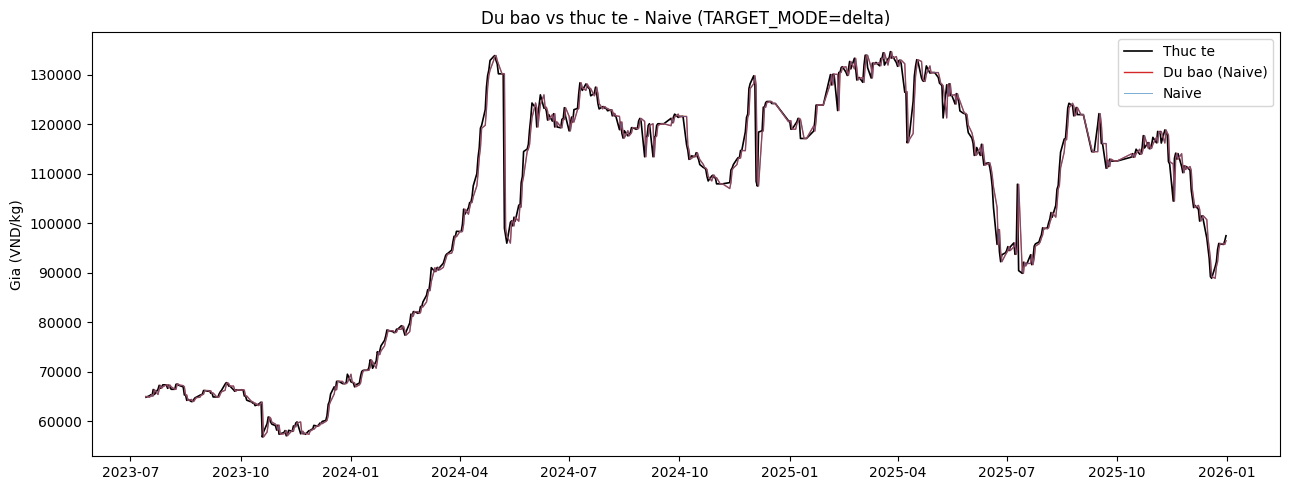

In [24]:
best = res.iloc[0]['Model']
plt.figure(figsize=(13,5))
plt.plot(eval_idx, y_true, label='Thuc te', color='black', lw=1.2)
plt.plot(eval_idx, preds_store[best], label='Du bao (' + best + ')', color='tab:red', lw=1)
plt.plot(eval_idx, preds_store['Naive'], label='Naive', color='tab:blue', lw=0.7, alpha=0.6)
plt.title('Du bao vs thuc te - ' + best + ' (TARGET_MODE=' + TARGET_MODE + ')')
plt.ylabel('Gia (VND/kg)'); plt.legend(); plt.tight_layout()
plt.savefig('forecast_best_model.png', dpi=120)
plt.show()

## 11. Feature importance

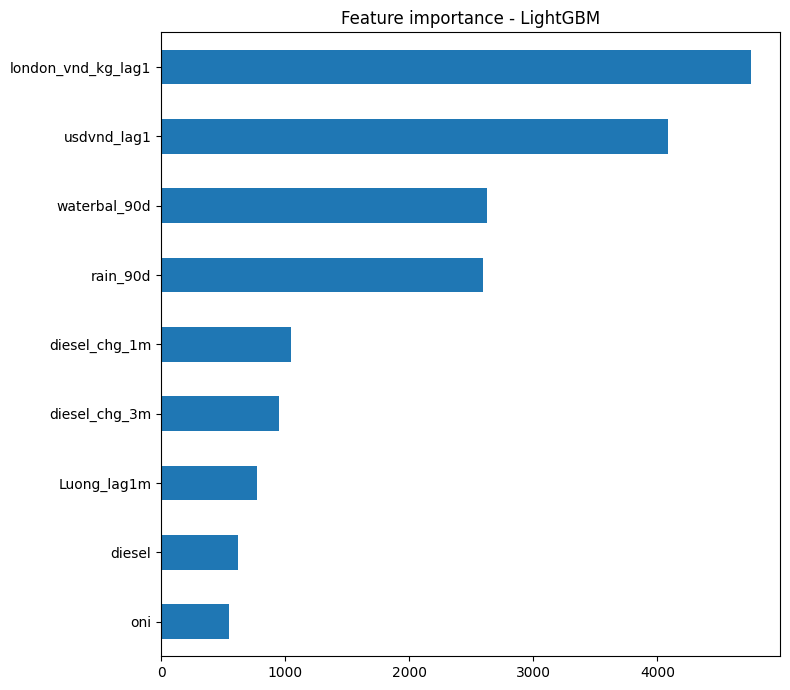

london_vnd_kg_lag1    4750
usdvnd_lag1           4083
waterbal_90d          2630
rain_90d              2593
diesel_chg_1m         1049
diesel_chg_3m          951
Luong_lag1m            773
diesel                 623
oni                    548
dtype: int32


In [25]:
# LUU Y: cell nay fit tren TOAN BO du lieu (gom ca test) -> chi dung MO TA
# do quan trong feature, KHONG dung de chon feature (selection bias).
tree_pref = [m for m in ['LightGBM','XGBoost','RandomForest'] if m in MODELS]
imp_name = next((c for c in tree_pref if c in res['Model'].values), 'RandomForest')

mdl = MODELS[imp_name]()
mdl.fit(X, y_model)
imp = getattr(mdl, 'feature_importances_', None)
if imp is not None:
    fi = pd.Series(imp, index=FEATURES).sort_values()
    fi.plot(kind='barh', figsize=(8,7), title='Feature importance - ' + imp_name)
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=120); plt.show()
    print(fi.sort_values(ascending=False))
else:
    print('Model', imp_name, 'khong co feature_importances_')

## 12. Kiem dinh Diebold-Mariano (vs Naive)

|DM| > 1.96 => chenh lech sai so co y nghia thong ke 5%.

In [26]:
def diebold_mariano(y, p1, p2, h=1):
    # loss = squared error; DM>0: p1 te hon p2
    d = (y - p1) ** 2 - (y - p2) ** 2
    d = d[np.isfinite(d)]
    nn = len(d)
    var = np.var(d, ddof=0)
    for k in range(1, h):
        var += 2 * np.cov(d[k:], d[:-k])[0, 1]
    return float(d.mean() / np.sqrt(var / nn))

pb = np.asarray(preds_store[best], float)
pn = np.asarray(preds_store['Naive'], float)
msk = np.isfinite(pb) & np.isfinite(pn)
dm = diebold_mariano(y_true[msk], pb[msk], pn[msk], h=1)
print('DM (' + best + ' vs Naive) =', round(dm, 3), ' (|DM|>1.96 => khac biet co y nghia 5%)')

DM (Naive vs Naive) = nan  (|DM|>1.96 => khac biet co y nghia 5%)


C:\Users\quangbeone\AppData\Local\Temp\ipykernel_27776\2637148668.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return float(d.mean() / np.sqrt(var / nn))


## 13. Ket luan & buoc tiep

- So sanh **RMSE/MAE/MASE** giua cac model; **MASE < 1** nghia la thang naive.
- **DA(%)** cao = du bao dung huong tot (quan trong cho quyet dinh mua/ban).
- Doi `TARGET_MODE` giua `level` va `delta` de xem anh huong cua viec ngoai suy.
- Buoc tiep: (1) tune hyperparameter (GridSearch theo thoi gian); (2) **ablation** bo bot feature trung (rain_90d vs waterbal_90d, diesel_chg_1m vs 3m, usdvnd vs london_vnd); (3) thu hybrid (tuyen tinh + cay hoc phan du).